In [1]:
import pandas as pd
import numpy as np
parent_dir = "/home/connorlab/Documents/GitHub/Julie/social_data/zombies_social_data/"
# Load data
aff_df = pd.read_excel(parent_dir + "zombies_feature_df_affiliation.xlsx", index_col=0)
sub_df = pd.read_excel(parent_dir + "zombies_feature_df_submission.xlsx", index_col=0)
ago_df = pd.read_excel(parent_dir + "zombies_feature_df_agonism.xlsx", index_col=0)

In [2]:
# 함수: "Behavior Towards 94B" → "94B"
def clean_col(colname):
    return colname.split()[-1]  # 마지막 단어만 추출

# 컬럼 이름 정리
aff_df.columns = [clean_col(c) for c in aff_df.columns]
sub_df.columns = [clean_col(c) for c in sub_df.columns]
ago_df.columns = [clean_col(c) for c in ago_df.columns]


# 공통 monkey 추출
monkeys = aff_df.index.intersection(sub_df.index).intersection(ago_df.index)

In [3]:
# Build behavior vector per monkey (row-wise vector from each matrix)
X = []
for m in monkeys:
    v = np.concatenate([
        aff_df.loc[m].values,
        sub_df.loc[m].values,
        ago_df.loc[m].values
    ])
    X.append(v)
X = np.array(X)
X

array([[ 0, 19,  9, 38, 84, 27, 13, 14,  4,  9,  0,  0,  0,  1,  0,  1,
         0,  0,  2,  0,  0,  4,  2,  7,  4,  7,  3,  9,  3,  2],
       [15,  0,  9, 41,  4, 13, 19, 71, 12,  0,  4,  0,  0, 13,  0,  0,
         0,  2,  1,  0,  0,  0,  0,  2,  1,  1,  8,  4,  2,  0],
       [18, 10,  0, 21,  7, 17, 49, 18,  3,  1,  9,  2,  0, 10,  0,  0,
         4,  3,  0,  0,  0,  1,  0,  0,  0,  7,  0,  1,  0,  2],
       [38, 43, 24,  0, 18,  6, 31, 26, 29,  4,  7,  0,  2,  0,  0,  0,
         0,  1,  6,  0,  1,  8,  0,  0,  9,  5,  6, 10, 11,  2],
       [90,  3,  8,  8,  0, 22,  8,  9,  1, 18, 11,  8,  3, 15,  0,  2,
         4,  2,  4, 18,  0,  0,  0,  0,  0,  1,  0,  1,  3, 10],
       [23, 12, 17,  1, 23,  0, 23, 16,  3, 10, 90, 16, 14, 43,  0,  0,
        10,  7,  9,  6,  0,  0,  0,  0,  2,  0,  0,  0,  3,  1],
       [17, 18, 43, 34, 10, 23,  0, 34,  2,  9, 29, 12,  1, 17,  0,  0,
         0, 23, 17,  1,  0,  0,  3,  2,  0,  4,  0,  1,  0,  6],
       [11, 70, 18, 17,  8, 17, 33,  0,  

In [14]:
# MDS
from sklearn.metrics import pairwise_distances

# Example using correlation distance
dissimilarity_matrix = pairwise_distances(X, metric='correlation')  # shape: (n_monkeys, n_monkeys)


In [15]:
from sklearn.manifold import MDS

mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42)
mds_coords = mds.fit_transform(dissimilarity_matrix) 

/home/connorlab/Documents/GitHub/Julie/venv/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


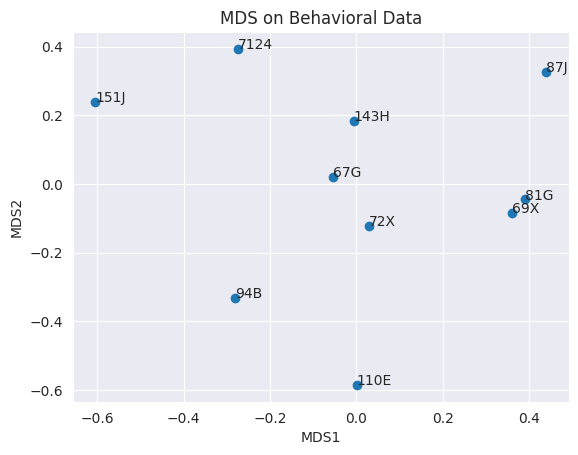

In [16]:
import matplotlib.pyplot as plt

plt.scatter(mds_coords[:, 0], mds_coords[:, 1])
for i, name in enumerate(monkeys):
    plt.text(mds_coords[i, 0], mds_coords[i, 1], name)
plt.title("MDS on Behavioral Data")
plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.grid(True)
plt.show()
